Comparison between our conditional metrics bounds and Eq. (11) bounds from 

_An adaptive nearest neighbor rule for classification_. Akshay Balsubramani, Sanjoy Dasgupta, Yoav Freund and Shay Moran. Advances in Neural Information Processing Systems 32 (NeurIPS 2019).

In [1]:
%run -i ../python_scripts/nb_setup.py

c:\Users\Emilien JEMELEN\Documents\SGR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from python_scripts.sgp_utils import emp_metric, our_bound

In [3]:
datasets = [
    "../experiments/CIFAR/sgp_set_cnn",
    "../experiments/CIFAR/sgp_set_cnn_MCD",
    "../experiments/WSI/sgp_set_cnn",
    "../experiments/WSI/sgp_set_cnn_MCD",
    "../experiments/CHEST/sgp_set_densenet_SR",
    "../experiments/DIABETES/sgp_set_tabular_SR",
]

In [4]:
num_points = 30

In [5]:
res_dicos = []
for dataset in datasets:

    print(dataset)

    if "CIFAR" in dataset:
        data = "CIFAR"
        model = "CNN"
    elif "WSI" in dataset:
        data = "WSI"
        model = "CNN"
    elif "CHEST" in dataset:
        data = "CHEST"
        model = "CNN"
    else:
        data = "DIABETES"
        model = "Trees"

    kappa = "MCD" if ("MCD" in dataset) else "SR"
    dataset = pickle.load(open(dataset, "rb"))

    train_set = dataset.iloc[: int(3 * len(dataset) / 4)]
    train_set = (
        train_set.sort_values("kappa", ascending=True).reset_index(drop=True).copy()
    )
    test_set = dataset.iloc[int(3 * len(dataset) / 4) :]

    thetas = (
        np.linspace(0.5, 1, num_points)[:-1]
        if (kappa == "SR")
        else np.linspace(-0.05, 0, num_points)[:-1]
    )

    for metric in ["FPR", "FNR"]:

        print(metric)

        our_bounds = []
        eq11_bounds = []
        detailed_eq11_bounds = []
        test_metrics = []

        for theta in tqdm(thetas):
            selected_samples = train_set.loc[train_set.kappa >= theta].copy()
            our_bounds.append(our_bound(selected_samples, metric))

            # Bound from eq (11)
            eq11_bounds.append(eq11_bound(selected_samples, metric))
            detailed_eq11_bounds.append(
                eq11_bound(selected_samples, metric, detailed=True)
            )

            try:
                # test metric
                test_metrics.append(
                    emp_metric(
                        test_set.loc[test_set.kappa >= theta].copy(), metric=metric
                    )
                )
            except ValueError:
                test_metrics.append(np.nan)

        res_dicos.append(
            {
                "data": data,
                "model": model,
                "kappa": kappa,
                "metric": metric,
                "our_bounds": our_bounds,
                "eq11_bounds": eq11_bounds,
                "detailed_eq11_bounds": detailed_eq11_bounds,
                "test_metrics": test_metrics,
            }
        )

../experiments/CIFAR/sgp_set_cnn
FPR


  0%|          | 0/29 [00:00<?, ?it/s]

100%|██████████| 29/29 [00:00<00:00, 136.79it/s]


FNR


100%|██████████| 29/29 [00:00<00:00, 182.38it/s]


...

100%|██████████| 29/29 [00:00<00:00, 123.96it/s]


../experiments/DIABETES/sgp_set_tabular_SR
FPR


100%|██████████| 29/29 [00:00<00:00, 145.53it/s]


FNR


100%|██████████| 29/29 [00:00<00:00, 199.99it/s]


In [6]:
df = pd.DataFrame(res_dicos)

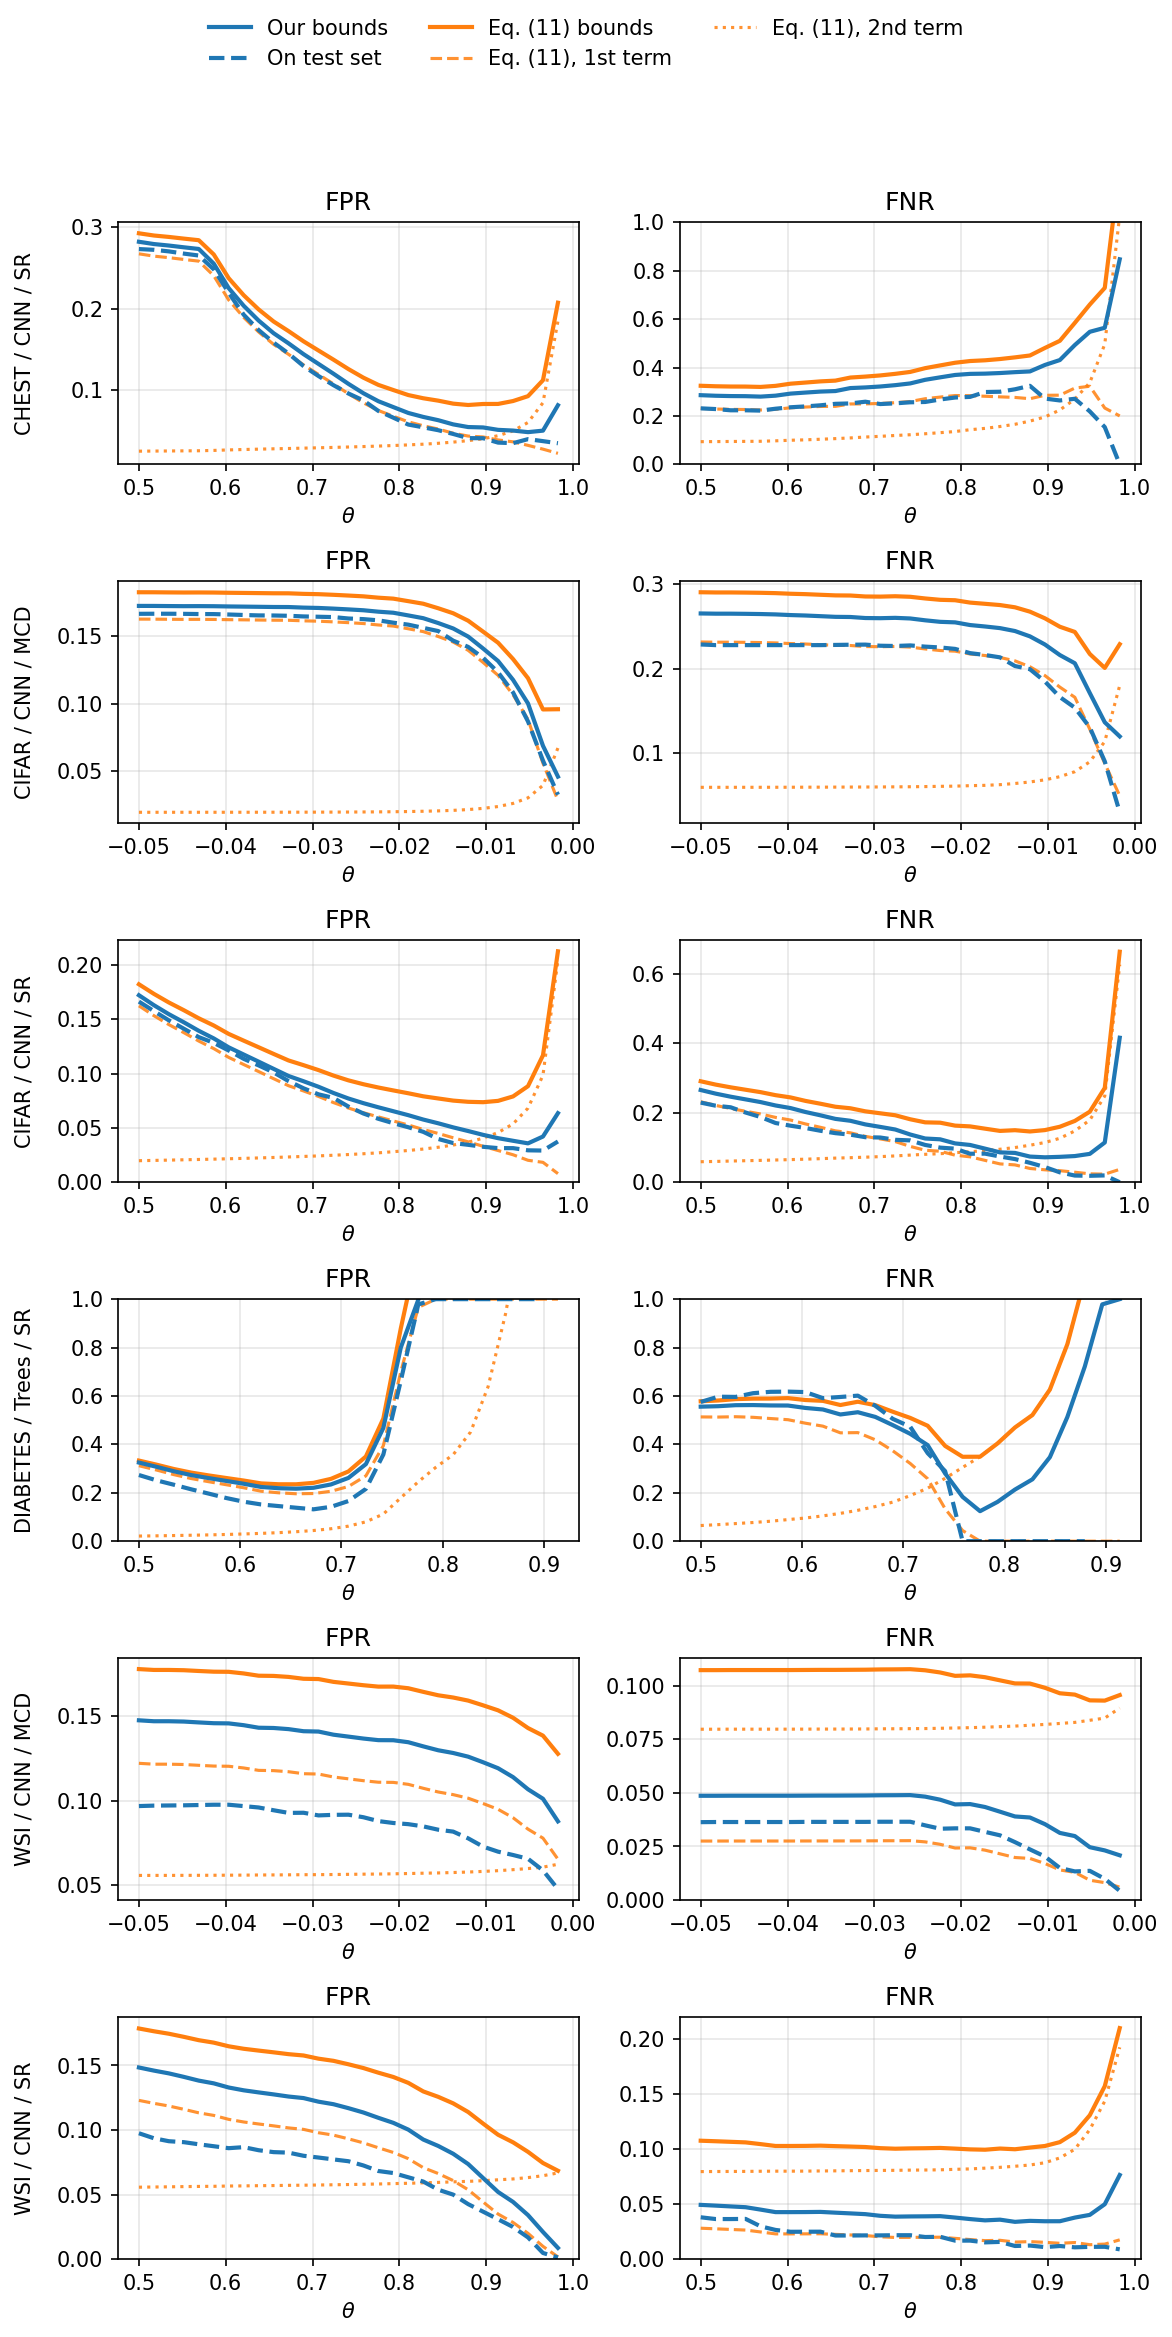

In [7]:
# --- helper: detailed_eq11_bounds -> (a, b)
def extract_ab(v):
    if isinstance(v, str):
        v = ast.literal_eval(v)
    arr = np.asarray(v, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f"detailed_eq11_bounds should be 2D, got shape {arr.shape}")
    if arr.shape[1] == 2:  # (n, 2)
        return arr[:, 0], arr[:, 1]
    if arr.shape[0] == 2:  # (2, n)
        return arr[0], arr[1]
    raise ValueError(f"Could not interpret detailed_eq11_bounds with shape {arr.shape}")


SHOW_EQ11_TERMS = True  # set False for the original 3-curve figure

# --- layout: one row per (data, model, kappa)
metrics_order = ["FPR", "FNR"]
combos = (
    df[["data", "model", "kappa"]]
    .drop_duplicates()
    .sort_values(["data", "model", "kappa"])
    .itertuples(index=False, name=None)
)
combos = list(combos)
nrows = len(combos)
ncols = len(metrics_order)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.3 * ncols, 2.6 * nrows),
    squeeze=False,
)

# terms first so the headline curves are drawn on top of them
series_cols = [
    "eq11_term_a",
    "eq11_term_b",
    "eq11_bounds",
    "our_bounds",
    "test_metrics",
]
legend_cols = [
    "our_bounds",
    "test_metrics",
    "eq11_bounds",
    "eq11_term_a",
    "eq11_term_b",
]

label_map = {
    "our_bounds": "Our bounds",
    "eq11_bounds": "Eq. (11) bounds",
    "test_metrics": "On test set",
    "eq11_term_a": "Eq. (11), 1st term",
    "eq11_term_b": "Eq. (11), 2nd term",
}

# --- style settings
style_map = {
    "our_bounds": dict(color="C0", linestyle="-"),
    "test_metrics": dict(color="C0", linestyle="--"),
    "eq11_bounds": dict(color="C1", linestyle="-"),
    "eq11_term_a": dict(color="C1", linestyle="--", linewidth=1.5, alpha=0.85),
    "eq11_term_b": dict(color="C1", linestyle=":", linewidth=1.5, alpha=0.85),
    "conformal_bounds": dict(color="C2", linestyle="-"),
}
LINEWIDTH = 2.0

handles_by_col = {}

for r, (data, model, kappa) in enumerate(combos):
    x = (
        np.linspace(0.5, 1, num_points)[:-1]
        if kappa == "SR"
        else np.linspace(-0.05, 0, num_points)[:-1]
    )

    sub = df[(df["data"] == data) & (df["model"] == model) & (df["kappa"] == kappa)]

    for c, metric in enumerate(metrics_order):
        ax = axes[r, c]
        row = sub[sub["metric"] == metric]
        if row.empty:
            ax.set_axis_off()
            continue

        row = row.iloc[0]

        panel = {
            sc: np.asarray(row[sc], dtype=float)
            for sc in ("our_bounds", "eq11_bounds", "test_metrics")
        }

        if SHOW_EQ11_TERMS and "detailed_eq11_bounds" in row.index:
            a, b = extract_ab(row["detailed_eq11_bounds"])
            panel["eq11_term_a"] = a
            panel["eq11_term_b"] = b

            max_err = np.max(np.abs(panel["eq11_bounds"] - (a + b)))
            if max_err > 1e-8:
                print(
                    f"[warn] {data}/{model}/{kappa}/{metric}: "
                    f"max |eq11 - (a+b)| = {max_err:.3e}"
                )

        for sc in series_cols:
            if sc not in panel:
                continue
            y = panel[sc]
            kw = dict(linewidth=LINEWIDTH)
            kw.update(style_map.get(sc, {}))
            (line,) = ax.plot(x[: len(y)], y, label=label_map[sc], **kw)
            handles_by_col.setdefault(sc, line)

        ax.set_title(metric)
        ax.set_xlabel(r"$\theta$")
        ax.grid(True, alpha=0.3)
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(max(0, ymin), min(1, ymax))

        if c == 0:
            ax.text(
                -0.18,
                0.5,
                f"{data} / {model} / {kappa}",
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="right",
            )

keys = [k for k in legend_cols if k in handles_by_col]
fig.legend(
    [handles_by_col[k] for k in keys],
    [label_map[k] for k in keys],
    loc="upper center",
    ncol=3,
    frameon=False,
)
fig.tight_layout(rect=[0.08, 0, 1, 0.93])
plt.show()